# xLSTM + Recurrent PPO: автоматическая торговля на MOEX
Реализация подхода из статьи *«A Deep Reinforcement Learning Approach to Automated Stock Trading, using xLSTM Networks»*
применительно к российскому рынку акций.

**Структура:**
1. Установка зависимостей
2. Загрузка данных с MOEX ISS
3. Feature engineering + turbulence index
4. Торговая среда (gymnasium)
5. xLSTM Policy для RecurrentPPO
6. Обучение
7. Тестирование + метрики из статьи (CR, MER, MPB, APPT, SR)

## Шаг 1: Установка зависимостей

In [ ]:
# Основные зависимости
!pip install stable-baselines3 sb3-contrib pandas numpy requests apimoex matplotlib

# xLSTM — официальная библиотека NX-AI (требует CUDA >= 8.0 для sLSTM backend)
!pip install git+https://github.com/NX-AI/xlstm.git

# Если нет подходящей GPU — используем только mLSTM блоки (работают на CPU)
# В этом случае в конфиге ниже slstm_at=[] (пустой список)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.0/93.0 kB 11.3 MB/s eta 0:00:00
  Cloning https://github.com/NX-AI/xlstm.git to /tmp/pip-req-build-rc34qc1u
  Running command git clone --filter=blob:none --quiet https://github.com/NX-AI/xlstm.git /tmp/pip-req-build-rc34qc1u
  Resolved https://github.com/NX-AI/xlstm.git to commit 032a6fb8ee19a8c0db80ae6111ff4744a09414a9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 97.3 MB/s eta 0:00:00
  Created wheel for x

## Шаг 2: Загрузка данных с MOEX ISS

In [ ]:
import pandas as pd
import numpy as np
import requests
import apimoex
import warnings
warnings.filterwarnings('ignore')

In [ ]:

# ── Конфигурация ──────────────────────────────────────────────────────────────
TICKERS = ['SBER', 'GAZP', 'LKOH', 'YNDX', 'GMKN']  # аналог NVDA/AAPL/MSFT/GOOG/AMZN
TRAIN_START = '2009-01-01'
TRAIN_END   = '2021-12-31'
TEST_START  = '2022-01-01'
TEST_END    = '2024-01-01'
DATA_FILE   = 'moex_data.csv'   # кэш — скачиваем один раз


def download_moex_ohlcv(ticker: str, start: str, end: str) -> pd.DataFrame:
    """
    Скачивает OHLCV данные с MOEX ISS через apimoex.
    Возвращает DataFrame с колонками: open, high, low, close, volume.
    Индекс — дата торгов.
    """
    with requests.Session() as session:
        # get_board_history отдаёт исторические данные основного режима (TQBR)
        data = apimoex.get_board_history(
            session, ticker,
            start=start, end=end,
            columns=('TRADEDATE', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME')
        )
    if not data:
        raise ValueError(f"Нет данных для {ticker} за период {start}–{end}")

    df = pd.DataFrame(data)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df = df.set_index('TRADEDATE')
    df.columns = [c.lower() for c in df.columns]          # open/high/low/close/volume
    df = df.add_prefix(f'{ticker}_')                       # sber_open, sber_close …
    df = df.replace(0, np.nan)                             # нули в ценах — пропуски
    return df


def load_or_download(tickers, start, end, cache_file):
    """Загружает из кэша или скачивает с MOEX."""
    import os
    if os.path.exists(cache_file):
        print(f"Загружаем из кэша: {cache_file}")
        df = pd.read_csv(cache_file, index_col=0, parse_dates=True)
        return df

    print("Скачиваем данные с MOEX ISS...")
    frames = []
    for t in tickers:
        print(f"  {t}...", end=' ', flush=True)
        frames.append(download_moex_ohlcv(t, start, end))
        print("OK")

    df = pd.concat(frames, axis=1)
    # Заполняем пропуски (праздничные дни MOEX отличаются от NYSE)
    df = df.ffill().bfill()
    df.to_csv(cache_file)
    print(f"Сохранено в {cache_file}")
    return df


# Скачиваем весь диапазон сразу, потом делим на train/test
raw = load_or_download(TICKERS, TRAIN_START, TEST_END, DATA_FILE)
print(f"\nДанные загружены: {raw.shape[0]} дней, {raw.shape[1]} колонок")
print(raw.head())

## Шаг 3: Feature engineering + Turbulence Index

In [ ]:
def extract_close_prices(df: pd.DataFrame, tickers: list) -> pd.DataFrame:
    """Вытаскивает только close-цены в отдельный DataFrame."""
    cols = [f'{t}_close' for t in tickers]
    return df[cols].copy()


def compute_turbulence(close_prices: pd.DataFrame, lookback: int = 252) -> pd.Series:
    """
    Turbulence index из статьи (уравнение 1):
        turbulence_t = (y_t - mu)^T * Sigma^{-1} * (y_t - mu)
    где y_t — вектор доходностей в момент t,
    mu и Sigma считаются по скользящему окну.
    """
    returns = close_prices.pct_change().dropna()
    turbulence = pd.Series(index=returns.index, dtype=float, name='turbulence')

    for i in range(lookback, len(returns)):
        hist = returns.iloc[i - lookback:i]
        mu = hist.mean().values
        cov = hist.cov().values
        y = returns.iloc[i].values - mu
        try:
            cov_inv = np.linalg.pinv(cov)   # псевдообратная — устойчива к сингулярности
            turb = float(y @ cov_inv @ y)
        except Exception:
            turb = 0.0
        turbulence.iloc[i] = max(turb, 0.0)

    turbulence = turbulence.fillna(0.0)
    return turbulence


def compute_features(df: pd.DataFrame, tickers: list) -> np.ndarray:
    """
    Признаки для каждой акции на каждый день:
    [open, high, low, close, volume] — как в статье (6 фич × n_assets)
    + нормализация min-max по обучающей выборке.
    Возвращает массив shape (T, n_features).
    """
    feature_list = []
    for t in tickers:
        cols = [f'{t}_{c}' for c in ['open', 'high', 'low', 'close', 'volume']]
        sub = df[cols].copy()
        # Нормализуем каждую колонку через z-score
        sub = (sub - sub.mean()) / (sub.std() + 1e-8)
        feature_list.append(sub.values)

    return np.concatenate(feature_list, axis=1).astype(np.float32)


# ── Вычисляем всё ─────────────────────────────────────────────────────────────
close_prices = extract_close_prices(raw, TICKERS)

print("Считаем turbulence index (займёт ~1–2 мин)...")
turbulence = compute_turbulence(close_prices)

# Порог: 75-й перцентиль по обучающей выборке — как принято в литературе
turb_train = turbulence[TRAIN_START:TRAIN_END]
TURBULENCE_THRESHOLD = float(np.percentile(turb_train.dropna(), 75))
print(f"Turbulence threshold (75th pct, train): {TURBULENCE_THRESHOLD:.2f}")

# Выравниваем индексы (первые lookback дней turbulence = NaN)
common_idx = raw.index.intersection(turbulence.dropna().index)
raw_aligned = raw.loc[common_idx]
turb_aligned = turbulence.loc[common_idx]

features_all = compute_features(raw_aligned, TICKERS)
close_all    = close_prices.loc[common_idx].values.astype(np.float32)
dates_all    = raw_aligned.index

# Train / Test split
train_mask = (dates_all >= TRAIN_START) & (dates_all <= TRAIN_END)
test_mask  = (dates_all >= TEST_START)  & (dates_all <= TEST_END)

features_train = features_all[train_mask]
close_train    = close_all[train_mask]
turb_train_arr = turb_aligned[train_mask].values

features_test  = features_all[test_mask]
close_test     = close_all[test_mask]
turb_test_arr  = turb_aligned[test_mask].values

print(f"\nTrain: {features_train.shape[0]} дней")
print(f"Test:  {features_test.shape[0]} дней")
print(f"Feature dim: {features_train.shape[1]}")

Считаем turbulence index (займёт ~1–2 мин)...
Turbulence threshold (75th pct, train): 6.05

Train: 2211 дней
Test:  506 дней
Feature dim: 25


## Шаг 4: Торговая среда (Gymnasium)

In [ ]:
import gymnasium as gym
from gymnasium import spaces


class MOEXTradingEnv(gym.Env):
    """
    Торговая среда для российского рынка акций.

    Observation: окно из window_size последних дней признаков
                 shape = (window_size, n_features)

    Action: непрерывный вектор торговых решений shape = (n_assets,)
            положительное значение → покупка, отрицательное → продажа.
            Масштаб action нормируется внутри step().

    Reward: реализован как в Algorithm 2 из статьи:
            turbulence check → portfolio value change − transaction cost → normalize
    """

    metadata = {'render_modes': []}

    def __init__(
        self,
        close_prices: np.ndarray,       # (T, n_assets)
        features: np.ndarray,           # (T, n_features)
        turbulence: np.ndarray,         # (T,)
        turbulence_threshold: float,
        initial_balance: float = 1_000_000.0,
        window_size: int = 30,
        commission: float = 0.0005,     # 0.05% — стандарт MOEX
        max_shares_per_trade: int = 100,
    ):
        super().__init__()
        self.close_prices = close_prices
        self.features = features
        self.turbulence = turbulence
        self.turbulence_threshold = turbulence_threshold
        self.initial_balance = initial_balance
        self.window_size = window_size
        self.commission = commission
        self.max_shares = max_shares_per_trade
        self.n_assets = close_prices.shape[1]
        self.n_features = features.shape[1]

        self.action_space = spaces.Box(
            low=-1.0, high=1.0,
            shape=(self.n_assets,), dtype=np.float32
        )
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(window_size, self.n_features), dtype=np.float32
        )

    # ── Gymnasium API ──────────────────────────────────────────────────────────

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.balance = self.initial_balance
        self.shares_held = np.zeros(self.n_assets, dtype=np.float32)
        self.prev_portfolio_value = self.initial_balance
        self.portfolio_history = [self.initial_balance]
        self.trade_count = 0
        return self._get_obs(), {}

    def step(self, action: np.ndarray):
        # ── Turbulence check (Algorithm 2, строки 2–6) ────────────────────────
        turb = self.turbulence[self.current_step]
        if turb > self.turbulence_threshold:
            # На высоковолатильном рынке не торгуем — штраф
            reward = -1.0
            self.current_step += 1
            done = self.current_step >= len(self.close_prices)
            self.portfolio_history.append(self._portfolio_value())
            return self._get_obs(), reward, done, False, {'turbulence': turb}

        # ── Исполнение сделки ─────────────────────────────────────────────────
        prices = self.close_prices[self.current_step]

        # Переводим action в количество акций (целые числа, ограниченные max_shares)
        shares_delta = (action * self.max_shares).astype(np.float32)

        # Нельзя продать больше, чем держим
        shares_delta = np.maximum(shares_delta, -self.shares_held)

        # Нельзя купить на сумму больше доступного баланса
        buy_cost = np.sum(np.maximum(shares_delta, 0) * prices)
        if buy_cost > self.balance:
            scale = self.balance / (buy_cost + 1e-8)
            shares_delta = np.where(shares_delta > 0, shares_delta * scale, shares_delta)

        trade_volume = np.sum(np.abs(shares_delta) * prices)
        transaction_cost = trade_volume * self.commission

        self.balance -= np.sum(shares_delta * prices) + transaction_cost
        self.shares_held += shares_delta
        self.trade_count += int(np.any(shares_delta != 0))

        # ── Переходим к следующему дню ────────────────────────────────────────
        self.current_step += 1
        done = self.current_step >= len(self.close_prices)

        new_value = self._portfolio_value()
        self.portfolio_history.append(new_value)

        # ── Reward = нормированное изменение портфеля (Algorithm 2, строки 11–14) ──
        raw_reward = (new_value - self.prev_portfolio_value) / (self.prev_portfolio_value + 1e-8)
        reward = float(np.clip(raw_reward, -1.0, 1.0))   # нормализация
        self.prev_portfolio_value = new_value

        info = {
            'portfolio_value': new_value,
            'balance': self.balance,
            'turbulence': turb,
        }
        return self._get_obs(), reward, done, False, info

    def render(self):
        val = self._portfolio_value()
        ret = (val - self.initial_balance) / self.initial_balance * 100
        print(f"День {self.current_step:4d} | Портфель: {val:>14,.0f} ₽ | Доходность: {ret:+.2f}%")

    # ── Вспомогательные методы ─────────────────────────────────────────────────

    def _get_obs(self) -> np.ndarray:
        start = self.current_step - self.window_size
        return self.features[start:self.current_step].copy()

    def _portfolio_value(self) -> float:
        idx = min(self.current_step, len(self.close_prices) - 1)
        return float(self.balance + np.sum(self.shares_held * self.close_prices[idx]))


# ── Создаём окружения ─────────────────────────────────────────────────────────
env_train = MOEXTradingEnv(
    close_prices=close_train,
    features=features_train,
    turbulence=turb_train_arr,
    turbulence_threshold=TURBULENCE_THRESHOLD,
    window_size=30,
)

env_test = MOEXTradingEnv(
    close_prices=close_test,
    features=features_test,
    turbulence=turb_test_arr,
    turbulence_threshold=TURBULENCE_THRESHOLD,
    window_size=30,
)

print("Observation space:", env_train.observation_space.shape)
print("Action space:     ", env_train.action_space.shape)

# Быстрая проверка среды
obs, _ = env_train.reset()
action = env_train.action_space.sample()
obs2, reward, done, trunc, info = env_train.step(action)
print(f"\nСреда работает. Reward: {reward:.4f}, Portfolio: {info['portfolio_value']:,.0f} ₽")

Observation space: (30, 25)
Action space:      (5,)

Среда работает. Reward: -0.0020, Portfolio: 997,964 ₽


## Шаг 5: xLSTM Policy для RecurrentPPO

In [ ]:
import torch
import torch.nn as nn
from typing import Optional, Tuple, Union
import gymnasium as gym

from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.type_aliases import Schedule
from stable_baselines3.common.utils import get_device
from sb3_contrib import RecurrentPPO
from sb3_contrib.common.recurrent.policies import RecurrentActorCriticPolicy

from xlstm import (
    xLSTMBlockStack,
    xLSTMBlockStackConfig,
    mLSTMBlockConfig,
    mLSTMLayerConfig,
    sLSTMBlockConfig,
    sLSTMLayerConfig,
    FeedForwardConfig,
)


def build_xlstm_stack(
    embedding_dim: int,
    context_length: int,
    num_blocks: int = 4,
    use_slstm: bool = False,   # False если нет CUDA Compute >= 8.0
) -> xLSTMBlockStack:
    """
    Создаёт стек xLSTM блоков согласно параметрам из статьи.
    Embedding dim = 128, активация GeLU (через FeedForwardConfig).

    use_slstm=False  → только mLSTM блоки (работают на любом железе)
    use_slstm=True   → mLSTM + sLSTM (как в оригинальной статье, нужен CUDA 8.0+)
    """
    if use_slstm:
        cfg = xLSTMBlockStackConfig(
            mlstm_block=mLSTMBlockConfig(
                mlstm=mLSTMLayerConfig(
                    conv1d_kernel_size=4,
                    qkv_proj_blocksize=4,
                    num_heads=4,
                )
            ),
            slstm_block=sLSTMBlockConfig(
                slstm=sLSTMLayerConfig(
                    backend='cuda',
                    num_heads=4,
                    conv1d_kernel_size=4,
                    bias_init='powerlaw_blockdependent',
                ),
                feedforward=FeedForwardConfig(proj_factor=1.3, act_fn='gelu'),
            ),
            context_length=context_length,
            num_blocks=num_blocks,
            embedding_dim=embedding_dim,
            slstm_at=[1],   # первый блок — sLSTM, остальные — mLSTM
        )
    else:
        # Только mLSTM — работает на CPU и любой GPU
        cfg = xLSTMBlockStackConfig(
            mlstm_block=mLSTMBlockConfig(
                mlstm=mLSTMLayerConfig(
                    conv1d_kernel_size=4,
                    qkv_proj_blocksize=4,
                    num_heads=4,
                )
            ),
            context_length=context_length,
            num_blocks=num_blocks,
            embedding_dim=embedding_dim,
            slstm_at=[],   # нет sLSTM блоков
        )
    return xLSTMBlockStack(cfg)


# ── xLSTM как FeaturesExtractor ────────────────────────────────────────────────
# Подход: используем xLSTM как feature encoder поверх стандартного
# RecurrentActorCriticPolicy. xLSTM обрабатывает всё окно наблюдений
# и отдаёт embedding последнего шага во встроенный LSTM политики.
# Встроенный LSTM sb3-contrib сохраняет hidden state между шагами среды.
# Это соответствует архитектуре статьи: xLSTM как encoder + recurrent policy.

class xLSTMEncoder(BaseFeaturesExtractor):
    """
    xLSTM encoder для observation пространства shape (window_size, n_features).

    Шаги:
    1. Linear projection: n_features → embedding_dim (128 как в статье)
    2. xLSTMBlockStack: (batch, window_size, embedding_dim) → то же
    3. Берём последний временной шаг: (batch, embedding_dim)
    """

    def __init__(
        self,
        observation_space: gym.spaces.Box,
        embedding_dim: int = 128,
        num_blocks: int = 4,
        use_slstm: bool = False,
    ):
        super().__init__(observation_space, features_dim=embedding_dim)

        window_size, n_features = observation_space.shape

        # Проекция входных признаков в embedding_dim
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, embedding_dim),
            nn.GELU(),
        )

        # xLSTM стек (embedding_dim должен совпадать с xLSTM embedding_dim)
        self.xlstm = build_xlstm_stack(
            embedding_dim=embedding_dim,
            context_length=window_size,
            num_blocks=num_blocks,
            use_slstm=use_slstm,
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        # observations: (batch, window_size, n_features)
        x = self.input_proj(observations)       # → (batch, window_size, embedding_dim)
        x = self.xlstm(x)                       # → (batch, window_size, embedding_dim)
        return x[:, -1, :]                      # → (batch, embedding_dim)

# ── Проверка энкодера ──────────────────────────────────────────────────────────

def check_slstm_available() -> bool:
    if not torch.cuda.is_available():
        return False
    cc_major = torch.cuda.get_device_capability()[0]
    return cc_major >= 8

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_SLSTM = check_slstm_available()
EMBEDDING_DIM = 128

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability()
    print(f"Compute Capability: {major}.{minor} ({'sLSTM OK' if USE_SLSTM else 'нужно >= 8.0 → используем mLSTM'})")
print(f"Используем sLSTM: {USE_SLSTM}")

test_encoder = xLSTMEncoder(
    observation_space=env_train.observation_space,
    embedding_dim=EMBEDDING_DIM,
    use_slstm=USE_SLSTM,
).to(DEVICE)

dummy_obs = torch.zeros(2, *env_train.observation_space.shape).to(DEVICE)
dummy_out = test_encoder(dummy_obs)
print(f"\nEncoder output shape: {dummy_out.shape}  (ожидается: [2, {EMBEDDING_DIM}])")
del test_encoder, dummy_obs, dummy_out

Device: cuda
Compute Capability: 7.5 (нужно >= 8.0 → используем mLSTM)
Используем sLSTM: False

Encoder output shape: torch.Size([2, 128])  (ожидается: [2, 128])


## Шаг 6: Обучение модели

In [ ]:
from stable_baselines3.common.vec_env import DummyVecEnv

# ── Гиперпараметры из статьи ──────────────────────────────────────────────────
WINDOW_SIZE   = 30      # time_window=30 дал лучший результат в Table I
BATCH_SIZE    = 32      # batch_size=32 из статьи
TOTAL_STEPS   = 200_000
LEARNING_RATE = 3e-4

# RecurrentPPO требует VecEnv
vec_env_train = DummyVecEnv([lambda: MOEXTradingEnv(
    close_prices=close_train,
    features=features_train,
    turbulence=turb_train_arr,
    turbulence_threshold=TURBULENCE_THRESHOLD,
    window_size=WINDOW_SIZE,
)])

# Параметры policy: xLSTM encoder + встроенный LSTM RecurrentPPO для памяти между шагами
policy_kwargs = dict(
    features_extractor_class=xLSTMEncoder,
    features_extractor_kwargs=dict(
        embedding_dim=EMBEDDING_DIM,
        num_blocks=4,
        use_slstm=USE_SLSTM,
    ),
    lstm_hidden_size=128,     # hidden size встроенного LSTM (как в статье)
    n_lstm_layers=1,
    enable_critic_lstm=True,  # отдельный LSTM для critic — как в статье (actor + critic)
    net_arch=[],              # нет дополнительных MLP слоёв между LSTM и головами
)

# RecurrentPPO с xLSTM политикой
model = RecurrentPPO(
    policy='MlpLstmPolicy',
    env=vec_env_train,
    policy_kwargs=policy_kwargs,
    learning_rate=LEARNING_RATE,
    n_steps=128,
    batch_size=BATCH_SIZE,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    verbose=1,
    seed=42,
    tensorboard_log='./tb_logs/',
    device='auto',
)

print("Архитектура модели:")
print(model.policy)

print(f"\nНачинаем обучение: {TOTAL_STEPS:,} шагов...")
model.learn(total_timesteps=TOTAL_STEPS, progress_bar=True)
model.save('xlstm_recurrent_ppo_moex')
print("\nОбучение завершено. Модель сохранена.")

   7% ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14,590/200,000  [ 0:29:53 < 3:48:55 , 13 it/s ]

## Шаг 7: Тестирование и метрики из статьи

In [ ]:
def run_episode(model, env: MOEXTradingEnv) -> list:
    """
    Прогоняет один эпизод с RecurrentPPO.
    Правильно передаёт lstm_states и episode_starts между шагами.
    Возвращает историю стоимости портфеля.
    """
    obs, _ = env.reset()
    # RecurrentPPO требует (1, *obs_shape) — одна среда
    obs = obs[np.newaxis, ...]     # (1, window_size, n_features)

    lstm_states = None
    episode_starts = np.array([True])
    done = False

    while not done:
        action, lstm_states = model.predict(
            obs,
            state=lstm_states,
            episode_start=episode_starts,
            deterministic=True,
        )
        obs_raw, reward, terminated, truncated, info = env.step(action[0])
        obs = obs_raw[np.newaxis, ...]
        episode_starts = np.array([terminated or truncated])
        done = terminated or truncated

    return env.portfolio_history


def compute_metrics(portfolio_history: list, initial_balance: float, n_trades: int,
                    risk_free_rate: float = 0.16) -> dict:
    """
    Метрики из Table I статьи:
    - CR  (Cumulative Return)
    - MER (Max Earning Rate)
    - MPB (Maximum PullBack)
    - APPT (Average Profitability Per Trade)
    - SR  (Sharpe Ratio)

    risk_free_rate: годовая безрисковая ставка (для РФ ~16% на 2024, для US ~5%)
    """
    values = np.array(portfolio_history, dtype=float)
    P_init = initial_balance
    P_final = values[-1]

    # Cumulative Return
    CR = (P_final - P_init) / P_init * 100

    # Max Earning Rate
    MER = (values.max() - P_init) / P_init * 100

    # Maximum PullBack
    running_max = np.maximum.accumulate(values)
    drawdown = (values - running_max) / (running_max + 1e-8)
    MPB = abs(drawdown.min()) * 100

    # Average Profitability Per Trade (в тысячах рублей)
    APPT = (P_final - P_init) / max(n_trades, 1) / 1000

    # Sharpe Ratio (дневные доходности → годовой Sharpe)
    daily_returns = np.diff(values) / (values[:-1] + 1e-8)
    daily_rf = risk_free_rate / 252
    excess = daily_returns - daily_rf
    SR = (excess.mean() / (excess.std() + 1e-8)) * np.sqrt(252)

    return {'CR': CR, 'MER': MER, 'MPB': MPB, 'APPT': APPT, 'SR': SR}


# ── Загружаем модель и тестируем ──────────────────────────────────────────────
model_loaded = RecurrentPPO.load('xlstm_recurrent_ppo_moex', env=DummyVecEnv([
    lambda: MOEXTradingEnv(
        close_prices=close_test, features=features_test,
        turbulence=turb_test_arr, turbulence_threshold=TURBULENCE_THRESHOLD,
        window_size=WINDOW_SIZE,
    )
]))

print("=== ТЕСТИРОВАНИЕ НА MOEX (2022–2024) ===")
portfolio_hist = run_episode(model_loaded, env_test)

metrics = compute_metrics(
    portfolio_hist,
    initial_balance=env_test.initial_balance,
    n_trades=env_test.trade_count,
)

print(f"""
┌─────────────────────────────────────────────────┐
│              РЕЗУЛЬТАТЫ (MOEX)                  │
├────────────────────────────┬────────────────────┤
│ Метрика                    │ Значение           │
├────────────────────────────┼────────────────────┤
│ Cumulative Return (CR)     │ {metrics['CR']:>+.2f}%            │
│ Max Earning Rate (MER)     │ {metrics['MER']:>+.2f}%            │
│ Max PullBack (MPB)         │ {metrics['MPB']:>.2f}%             │
│ Avg Profit/Trade (APPT)    │ {metrics['APPT']:>.2f}k ₽          │
│ Sharpe Ratio (SR)          │ {metrics['SR']:>.3f}             │
│ Всего сделок               │ {env_test.trade_count:<20} │
└────────────────────────────┴────────────────────┘
""")

=== ТЕСТИРОВАНИЕ НА MOEX (2022–2024) ===

┌─────────────────────────────────────────────────┐
│              РЕЗУЛЬТАТЫ (MOEX)                  │
├────────────────────────────┬────────────────────┤
│ Метрика                    │ Значение           │
├────────────────────────────┼────────────────────┤
│ Cumulative Return (CR)     │ -11.26%            │
│ Max Earning Rate (MER)     │ +0.93%            │
│ Max PullBack (MPB)         │ 37.17%             │
│ Avg Profit/Trade (APPT)    │ -0.39k ₽          │
│ Sharpe Ratio (SR)          │ -0.432             │
│ Всего сделок               │ 292                  │
└────────────────────────────┴────────────────────┘



## Шаг 8: Визуализация

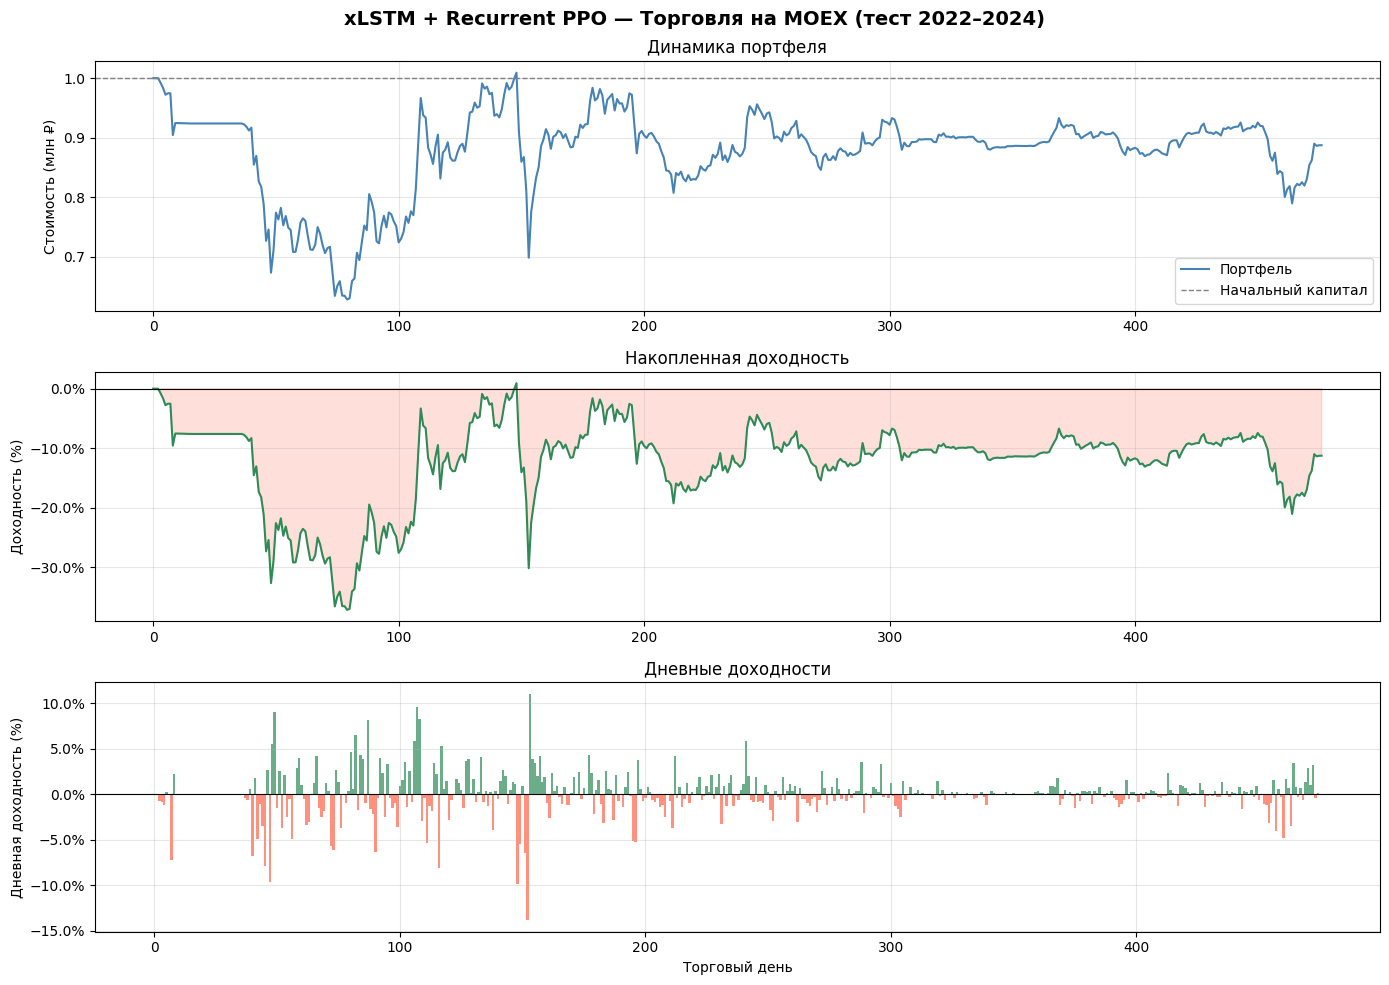

График сохранён: moex_xlstm_results.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

portfolio = np.array(portfolio_hist)
days = np.arange(len(portfolio))
returns_pct = (portfolio / env_test.initial_balance - 1) * 100
daily_rets = np.diff(portfolio) / portfolio[:-1] * 100

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle('xLSTM + Recurrent PPO — Торговля на MOEX (тест 2022–2024)',
             fontsize=14, fontweight='bold', y=0.98)

# 1. Стоимость портфеля
ax = axes[0]
ax.plot(days, portfolio / 1e6, color='steelblue', linewidth=1.5, label='Портфель')
ax.axhline(y=env_test.initial_balance / 1e6, color='gray', linestyle='--',
           linewidth=1, label='Начальный капитал')
ax.set_ylabel('Стоимость (млн ₽)')
ax.set_title('Динамика портфеля')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Накопленная доходность
ax = axes[1]
ax.plot(days, returns_pct, color='seagreen', linewidth=1.5)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.fill_between(days, returns_pct, 0,
                where=(returns_pct >= 0), alpha=0.2, color='seagreen')
ax.fill_between(days, returns_pct, 0,
                where=(returns_pct < 0),  alpha=0.2, color='tomato')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Доходность (%)')
ax.set_title('Накопленная доходность')
ax.grid(True, alpha=0.3)

# 3. Дневные доходности
ax = axes[2]
colors = ['seagreen' if r >= 0 else 'tomato' for r in daily_rets]
ax.bar(np.arange(len(daily_rets)), daily_rets, color=colors, alpha=0.7, width=1.0)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Торговый день')
ax.set_ylabel('Дневная доходность (%)')
ax.set_title('Дневные доходности')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('moex_xlstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: moex_xlstm_results.png")

## Шаг 9: Baseline — тот же код с обычным LSTM (для сравнения как в статье)

Запусти этот блок отдельно чтобы получить baseline метрики для Table I диплома.

In [ ]:
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor


class LSTMEncoder(BaseFeaturesExtractor):
    """Baseline encoder: обычный LSTM вместо xLSTM."""

    def __init__(self, observation_space: gym.spaces.Box, hidden_dim: int = 128):
        super().__init__(observation_space, features_dim=hidden_dim)
        _, n_features = observation_space.shape
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(obs)
        return out[:, -1, :]


baseline_policy_kwargs = dict(
    features_extractor_class=LSTMEncoder,
    features_extractor_kwargs=dict(hidden_dim=128),
    lstm_hidden_size=128,
    n_lstm_layers=1,
    enable_critic_lstm=True,
    net_arch=[],
)

vec_env_baseline = DummyVecEnv([lambda: MOEXTradingEnv(
    close_prices=close_train, features=features_train,
    turbulence=turb_train_arr, turbulence_threshold=TURBULENCE_THRESHOLD,
    window_size=WINDOW_SIZE,
)])

baseline_model = RecurrentPPO(
    policy='MlpLstmPolicy',
    env=vec_env_baseline,
    policy_kwargs=baseline_policy_kwargs,
    learning_rate=LEARNING_RATE,
    n_steps=128,
    batch_size=BATCH_SIZE,
    n_epochs=10,
    gamma=0.99,
    verbose=1,
    seed=42,
    device='auto',
)

print("Обучаем LSTM baseline...")
baseline_model.learn(total_timesteps=TOTAL_STEPS, progress_bar=True)
baseline_model.save('lstm_baseline_moex')

# Тест
env_test_baseline = MOEXTradingEnv(
    close_prices=close_test, features=features_test,
    turbulence=turb_test_arr, turbulence_threshold=TURBULENCE_THRESHOLD,
    window_size=WINDOW_SIZE,
)
baseline_hist = run_episode(baseline_model, env_test_baseline)
baseline_metrics = compute_metrics(
    baseline_hist, env_test_baseline.initial_balance, env_test_baseline.trade_count
)

# Итоговая таблица сравнения
print("\n" + "="*65)
print(f"{'Метрика':<28} {'LSTM (baseline)':>16} {'xLSTM (наша модель)':>18}")
print("-"*65)
for key in ['CR', 'MER', 'MPB', 'APPT', 'SR']:
    print(f"{key:<28} {baseline_metrics[key]:>16.3f} {metrics[key]:>18.3f}")
print("="*65)

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200,055/200,000  [ 0:20:38 < 0:00:00 , 166 it/s ]


Метрика                       LSTM (baseline) xLSTM (наша модель)
-----------------------------------------------------------------
CR                                    -11.114            -11.265
MER                                     0.000              0.927
MPB                                    25.441             37.172
APPT                                   -0.475             -0.386
SR                                     -0.747             -0.432
